In [1]:
import torch
from sdf_utils import sap
import time
import random
import deep_sdf
from deep_sdf import mesh, metrics, lr_scheduling, plotting, utils, loss, data
import deep_sdf.workspace as ws
import json
import os
import reconstruct
import numpy as np
import matplotlib.pyplot as plt
import networks.sdf_vae as vae
import logging

In [2]:
def get_spec_with_default(specs, key, default):
    try:
        return specs[key]
    except KeyError:
        return default

In [3]:
experiment_directory = "examples/torus/Run_w_Encoder_Decoder_KL_Contrastive"
#experiment_directory = "examples/torus_subgroup"
specs = ws.load_experiment_specifications(experiment_directory)
data_source = specs["DataSource"]
test_split_file = specs["TestSplit"]
train_split_file = specs["TrainSplit"]
data_source_mesh = specs["DataSourceMesh"]
with open(test_split_file, "r") as f:
    test_split = json.load(f)
eval_test_scene_num = get_spec_with_default(specs, "EvalTestSceneNumber", 10)
eval_test_optimization_steps = get_spec_with_default(specs, "EvalTestOptimizationSteps", 1000)
eval_grid_res = get_spec_with_default(specs, "EvalGridResolution", 256)
torus_path = get_spec_with_default(specs, "TorusPath", "/home/jakaria/torus_bump_5000_two_scale_binary_bump_variable_noise_fixed_angle_two_subgroup_bump/scaled_obj_files")

In [4]:
arch = __import__("networks." + specs["NetworkArch"], fromlist=["Decoder"])
latent_size = specs["CodeLength"]
num_samp_per_scene = specs["SamplesPerScene"]
decoder_specs = specs["NetworkSpecs"]
kl_div_loss = True

#decoder = arch.Decoder(latent_size, **specs["NetworkSpecs"])
decoder = vae.SDFVAE(latent_size, num_samp_per_scene, decoder_specs, kl_div_loss).cuda()
#decoder = torch.nn.DataParallel(decoder)

saved_model_state = torch.load(
    os.path.join(
        experiment_directory, ws.model_params_subdir, "latest" + ".pth"
    )
)
saved_model_epoch = saved_model_state["epoch"]

decoder.load_state_dict(saved_model_state["model_state_dict"])
#decoder = decoder.module.cuda()
decoder.eval()

SDFVAE(
  (encoder): DataParallel(
    (module): ResnetPointnet(
      (fc_pos): Linear(in_features=3, out_features=256, bias=True)
      (block_0): ResnetBlockFC(
        (fc_0): Linear(in_features=256, out_features=128, bias=True)
        (fc_1): Linear(in_features=128, out_features=128, bias=True)
        (actvn): ReLU()
        (shortcut): Linear(in_features=256, out_features=128, bias=False)
      )
      (block_1): ResnetBlockFC(
        (fc_0): Linear(in_features=256, out_features=128, bias=True)
        (fc_1): Linear(in_features=128, out_features=128, bias=True)
        (actvn): ReLU()
        (shortcut): Linear(in_features=256, out_features=128, bias=False)
      )
      (block_2): ResnetBlockFC(
        (fc_0): Linear(in_features=256, out_features=128, bias=True)
        (fc_1): Linear(in_features=128, out_features=128, bias=True)
        (actvn): ReLU()
        (shortcut): Linear(in_features=256, out_features=128, bias=False)
      )
      (block_3): ResnetBlockFC(
        

In [5]:
eval_test_time_start = time.time()
test_err_sum = 0.
chamfer_dists = []
chamfer_dists_all = []
test_loss_hists = []
mesh_label_names = []
test_latents = []
sap_scores = []
all_labels = []
all_labels_reg = []
all_labels_group = []
all_latents = []

In [6]:
eval_test_filenames = deep_sdf.data.get_instance_filenames(data_source, test_split)
labels = torch.load(data_source + "/labels.pt")
eval_test_filenames = random.sample(eval_test_filenames, max(eval_test_scene_num, len(eval_test_filenames)))

In [7]:
with open(train_split_file, "r") as f:
    train_split = json.load(f)

In [8]:
for test_fname in eval_test_filenames:
    save_name = os.path.basename(test_fname).split(".npz")[0]
    mesh_path = os.path.join(data_source_mesh, save_name + ".obj")
    test_surface_points = data.get_surface_points(mesh_path)
    test_surface_points = torch.from_numpy(test_surface_points)
    test_surface_points = test_surface_points.unsqueeze(0)
    label = labels.get(save_name)
    all_labels.append(label[0])
    all_labels_reg.append(label[2])
    #all_labels_group.append(label[4])
    mesh_label_names.append(save_name)
    path = os.path.join(experiment_directory, "contrastive", ws.tb_logs_test_reconstructions, save_name)
    if not os.path.exists(path):
        os.makedirs(path)
        
    test_fpath = os.path.join(data_source, ws.sdf_samples_subdir, test_fname)
    test_sdf_samples = deep_sdf.data.read_sdf_samples_into_ram(test_fpath)
    test_sdf_samples[0] = test_sdf_samples[0][torch.randperm(test_sdf_samples[0].shape[0])]
    test_sdf_samples[1] = test_sdf_samples[1][torch.randperm(test_sdf_samples[1].shape[0])]
 
    print(f"Creating mesh for {test_fname}...")
    test_latent = None
    start = time.time()
    with torch.no_grad():
        test_mesh, z = mesh.create_mesh(
            decoder, 
            kl_div_loss,
            test_surface_points,
            test_latent, 
            N=eval_grid_res, 
            max_batch=int(2 ** 18), 
            filename=os.path.join(path, f"epoch={saved_model_epoch}"),
            return_trimesh=True,
            return_latent=True
        )
    print(f"Mesh creation for {test_fname} took {time.time()-start} seconds.")

    all_latents.append(z)

    if test_mesh is not None:
        gt_mesh_path = f"{torus_path}/{save_name}.obj"
        cd, cd_all = metrics.compute_metric(gt_mesh=gt_mesh_path, gen_mesh=test_mesh, metric="chamfer")
        chamfer_dists.append(cd)
        chamfer_dists_all.append(cd_all)

        del test_sdf_samples, test_mesh

Creating mesh for /home/jakaria/torus_bump_5000_two_scale_binary_bump_variable_noise_fixed_angle/sdf_data/SdfSamples/scaled_obj_files/torus_bump_4717.npz...
Mesh creation for /home/jakaria/torus_bump_5000_two_scale_binary_bump_variable_noise_fixed_angle/sdf_data/SdfSamples/scaled_obj_files/torus_bump_4717.npz took 8.174331665039062 seconds.
Creating mesh for /home/jakaria/torus_bump_5000_two_scale_binary_bump_variable_noise_fixed_angle/sdf_data/SdfSamples/scaled_obj_files/torus_bump_3555.npz...
Mesh creation for /home/jakaria/torus_bump_5000_two_scale_binary_bump_variable_noise_fixed_angle/sdf_data/SdfSamples/scaled_obj_files/torus_bump_3555.npz took 5.615069389343262 seconds.
Creating mesh for /home/jakaria/torus_bump_5000_two_scale_binary_bump_variable_noise_fixed_angle/sdf_data/SdfSamples/scaled_obj_files/torus_bump_3601.npz...
Mesh creation for /home/jakaria/torus_bump_5000_two_scale_binary_bump_variable_noise_fixed_angle/sdf_data/SdfSamples/scaled_obj_files/torus_bump_3601.npz too

In [9]:
# Create a directory to store the metrics
metrics_dir = os.path.join(experiment_directory, "metrics")
os.makedirs(metrics_dir, exist_ok=True)

# Save the aggregated Chamfer distances
chamfer_path = os.path.join(metrics_dir, "chamfer_dists.npy")
np.save(chamfer_path, np.array(chamfer_dists))
print(f"Saved aggregated Chamfer distances to {chamfer_path}")

# Save the detailed point-wise Chamfer distances
chamfer_all_path = os.path.join(metrics_dir, "chamfer_dists_all.npy")
np.save(chamfer_all_path, np.array(chamfer_dists_all, dtype=object))
print(f"Saved detailed Chamfer distances to {chamfer_all_path}")

# Save the mapping between mesh names and their Chamfer distances
mesh_chamfer_mapping = {name: dist for name, dist in zip(mesh_label_names, chamfer_dists)}
with open(os.path.join(metrics_dir, "mesh_chamfer_mapping.json"), 'w') as f:
    json.dump(mesh_chamfer_mapping, f, indent=4)
print(f"Saved mesh to Chamfer distance mapping")

# Save all latents
latents_path = os.path.join(metrics_dir, "all_latents.npy")
all_latents_array = np.stack([l.detach().cpu().numpy() for l in all_latents], axis=0)
np.save(latents_path, all_latents_array)
print(f"Saved all latents to {latents_path}")

Saved aggregated Chamfer distances to examples/torus/Run_w_Encoder_Decoder_KL_Contrastive/metrics/chamfer_dists.npy
Saved detailed Chamfer distances to examples/torus/Run_w_Encoder_Decoder_KL_Contrastive/metrics/chamfer_dists_all.npy
Saved mesh to Chamfer distance mapping
Saved all latents to examples/torus/Run_w_Encoder_Decoder_KL_Contrastive/metrics/all_latents.npy


In [10]:
all_latents_array = all_latents_array.squeeze()
all_latents_array

array([[-8.79973888e+00, -2.79799080e+00, -3.63438427e-01,
        -2.19228312e-01,  9.17472839e-02, -4.55140583e-02,
        -2.06758761e+00,  1.33237153e-01,  5.63878536e-01,
         2.02736855e-01,  1.41997471e-01, -3.09162259e-01,
         3.76110464e-01, -5.42231977e-01, -1.70190305e-01,
         7.70493001e-02],
       [-8.79029465e+00,  1.46921188e-01, -3.48569363e-01,
        -4.85955328e-01,  3.84862304e-01,  2.67921150e-01,
        -3.68773460e+00,  3.61189723e-01,  6.97666228e-01,
         1.01649486e-01,  5.35534441e-01, -1.97131217e-01,
         6.53219283e-01, -7.94344723e-01, -3.25535685e-01,
         3.22343647e-01],
       [-8.71035480e+00, -4.07507509e-01, -1.21243805e-01,
         1.04259789e-01,  2.42267728e-01, -2.61717677e-01,
         7.65020788e-01,  2.25760579e-01,  6.16414472e-02,
        -2.81719584e-03, -1.27063140e-01,  1.70635760e-01,
         2.64991909e-01, -2.76499122e-01, -6.90767542e-02,
        -2.63058126e-01],
       [ 8.85117626e+00, -4.24357742e

In [26]:
chamfer_dists_all

[array([0.11392508, 0.09247757, 0.1395629 , ..., 0.11366191, 0.12126401,
        0.16303694]),
 array([0.00714836, 0.05622733, 0.03459026, ..., 0.04181832, 0.22116951,
        0.03513978]),
 array([0.03826157, 0.193398  , 0.0446397 , ..., 0.15559359, 0.16149119,
        0.13753107]),
 array([0.16506245, 0.03052809, 0.00759476, ..., 0.00980155, 0.16219318,
        0.12328924]),
 array([0.15100458, 0.13563212, 0.14217514, ..., 0.07266882, 0.03768978,
        0.0502288 ]),
 array([0.09305159, 0.12625686, 0.10329867, ..., 0.07636503, 0.22502017,
        0.08220789]),
 array([0.148218  , 0.13469481, 0.16082934, ..., 0.01654827, 0.06820117,
        0.2380349 ]),
 array([0.04127858, 0.1459955 , 0.19099013, ..., 0.13013286, 0.09976447,
        0.19246343]),
 array([0.10630882, 0.05691933, 0.12570056, ..., 0.14803399, 0.09559173,
        0.11372772]),
 array([0.10130959, 0.13207228, 0.0083702 , ..., 0.11458143, 0.14698638,
        0.08372972]),
 array([0.00828819, 0.05523076, 0.16160012, ..., 0

In [25]:
# for training sap score using train latents
latent_vectors = ws.load_latent_vectors(experiment_directory, "latest")

In [26]:
test_latents = latent_vectors.numpy()
test_latents

array([[-0.575435  , -0.6429782 ,  0.21160646, ...,  0.03933862,
        -0.24190675, -0.07234324],
       [-0.57545424,  0.69773245, -0.15127687, ..., -0.00168114,
        -0.10183123,  0.03091359],
       [ 0.5672975 , -0.08133214,  0.3046311 , ...,  0.1310711 ,
         0.1707137 ,  0.14857425],
       ...,
       [-0.5754347 , -0.22443031,  0.06833063, ..., -0.00332314,
         0.0990525 , -0.08580769],
       [ 0.567255  ,  0.70041424, -0.17240226, ..., -0.09431293,
         0.14982753,  0.07370416],
       [ 0.56730896,  0.74855626,  0.07426561, ..., -0.04787093,
         0.2086435 ,  0.08448878]], dtype=float32)

In [27]:
# Extract the base names (without .obj extension)
keys_to_extract = [name.replace('.obj', '') for name in train_split_file]
# Extract third column values for matching keys
third_column_values = []
first_column_values = []    
for key in keys_to_extract:
    if key in labels:  # Check if the key exists in the large label file
        third_column_values.append(labels[key][2])  # Get the third column value
        first_column_values.append(labels[key][0])

In [28]:
print(third_column_values)

[0.2575250836120402, 0.7591973244147154, 0.4816053511705687, 0.15719063545150513, 0.2876254180602005, 0.030100334448160737, 0.5183946488294313, 0.632107023411371, 0.8227424749163874, 0.2876254180602005, 0.45484949832775934, 0.6889632107023416, 0.41137123745819393, 0.7458193979933108, 0.8561872909698991, 0.5551839464882944, 0.9732441471571907, 0.3143812709030098, 0.5150501672240804, 0.7224080267558524, 0.15719063545150513, 0.6053511705685617, 0.056856187290970084, 0.9832775919732439, 0.6220735785953178, 0.7458193979933108, 0.38127090301003363, 0.7290969899665547, 0.2775919732441472, 0.14046822742474951, 0.6923076923076921, 0.3712374581939799, 0.18729096989966543, 0.7257525083612038, 0.5986622073578594, 0.6153846153846154, 0.3377926421404682, 0.7157190635451509, 0.08695652173913082, 0.11036789297658878, 0.9030100334448159, 0.2742474916387958, 0.1705685618729098, 0.9866220735785953, 0.5384615384615383, 0.6387959866220734, 0.57190635451505, 0.6153846153846154, 0.5652173913043477, 0.6755852

In [29]:
len(third_column_values), len(first_column_values)

(369, 369)

In [30]:
all_labels = np.array(first_column_values)
all_labels_reg = np.array(third_column_values)

In [ ]:
# for test latents and sap score
test_latents = torch.cat(test_latents)
test_latents = test_latents.cpu().detach().numpy()

In [12]:

all_labels = np.array(all_labels)
all_labels_reg = np.array(all_labels_reg)
all_labels_group = np.array(all_labels_group)

In [8]:
path = os.path.join(experiment_directory, "test_latents", "latent_vectors.npy")

In [ ]:
np.save(path, test_latents)

In [13]:
all_labels = all_labels.reshape(-1, 1)
all_labels_reg = all_labels_reg.reshape(-1, 1)
all_labels_group = all_labels_group.reshape(-1, 1)

In [17]:
print(f"Calculating SAP scores...")
print(f"latent size: {all_latents_array.shape}")
print(f"all_labels size: {all_labels.shape}")
print(f"all_labels_reg size: {all_labels_reg.shape}")
print(f"all_labels_group size: {all_labels_group.shape}")
sap_score_cls = sap(factors=all_labels, codes=all_latents_array, continuous_factors=False, regression=False)
sap_score_reg = sap(factors=all_labels_reg, codes=all_latents_array, continuous_factors=True, regression=True)
#sap_score_group = sap(factors=all_labels_group, codes=all_latents_array, continuous_factors=False, regression=False)

Calculating SAP scores...
latent size: (22, 16)
all_labels size: (22, 1)
all_labels_reg size: (22, 1)
all_labels_group size: (0, 1)


In [18]:
# contrastive vae
print(f"SAP score (classification): {sap_score_cls}")
print(f"SAP score (regression): {sap_score_reg}")
#print(f"SAP score (group): {sap_score_group}")

SAP score (classification): 0.0
SAP score (regression): 0.6774735495831642


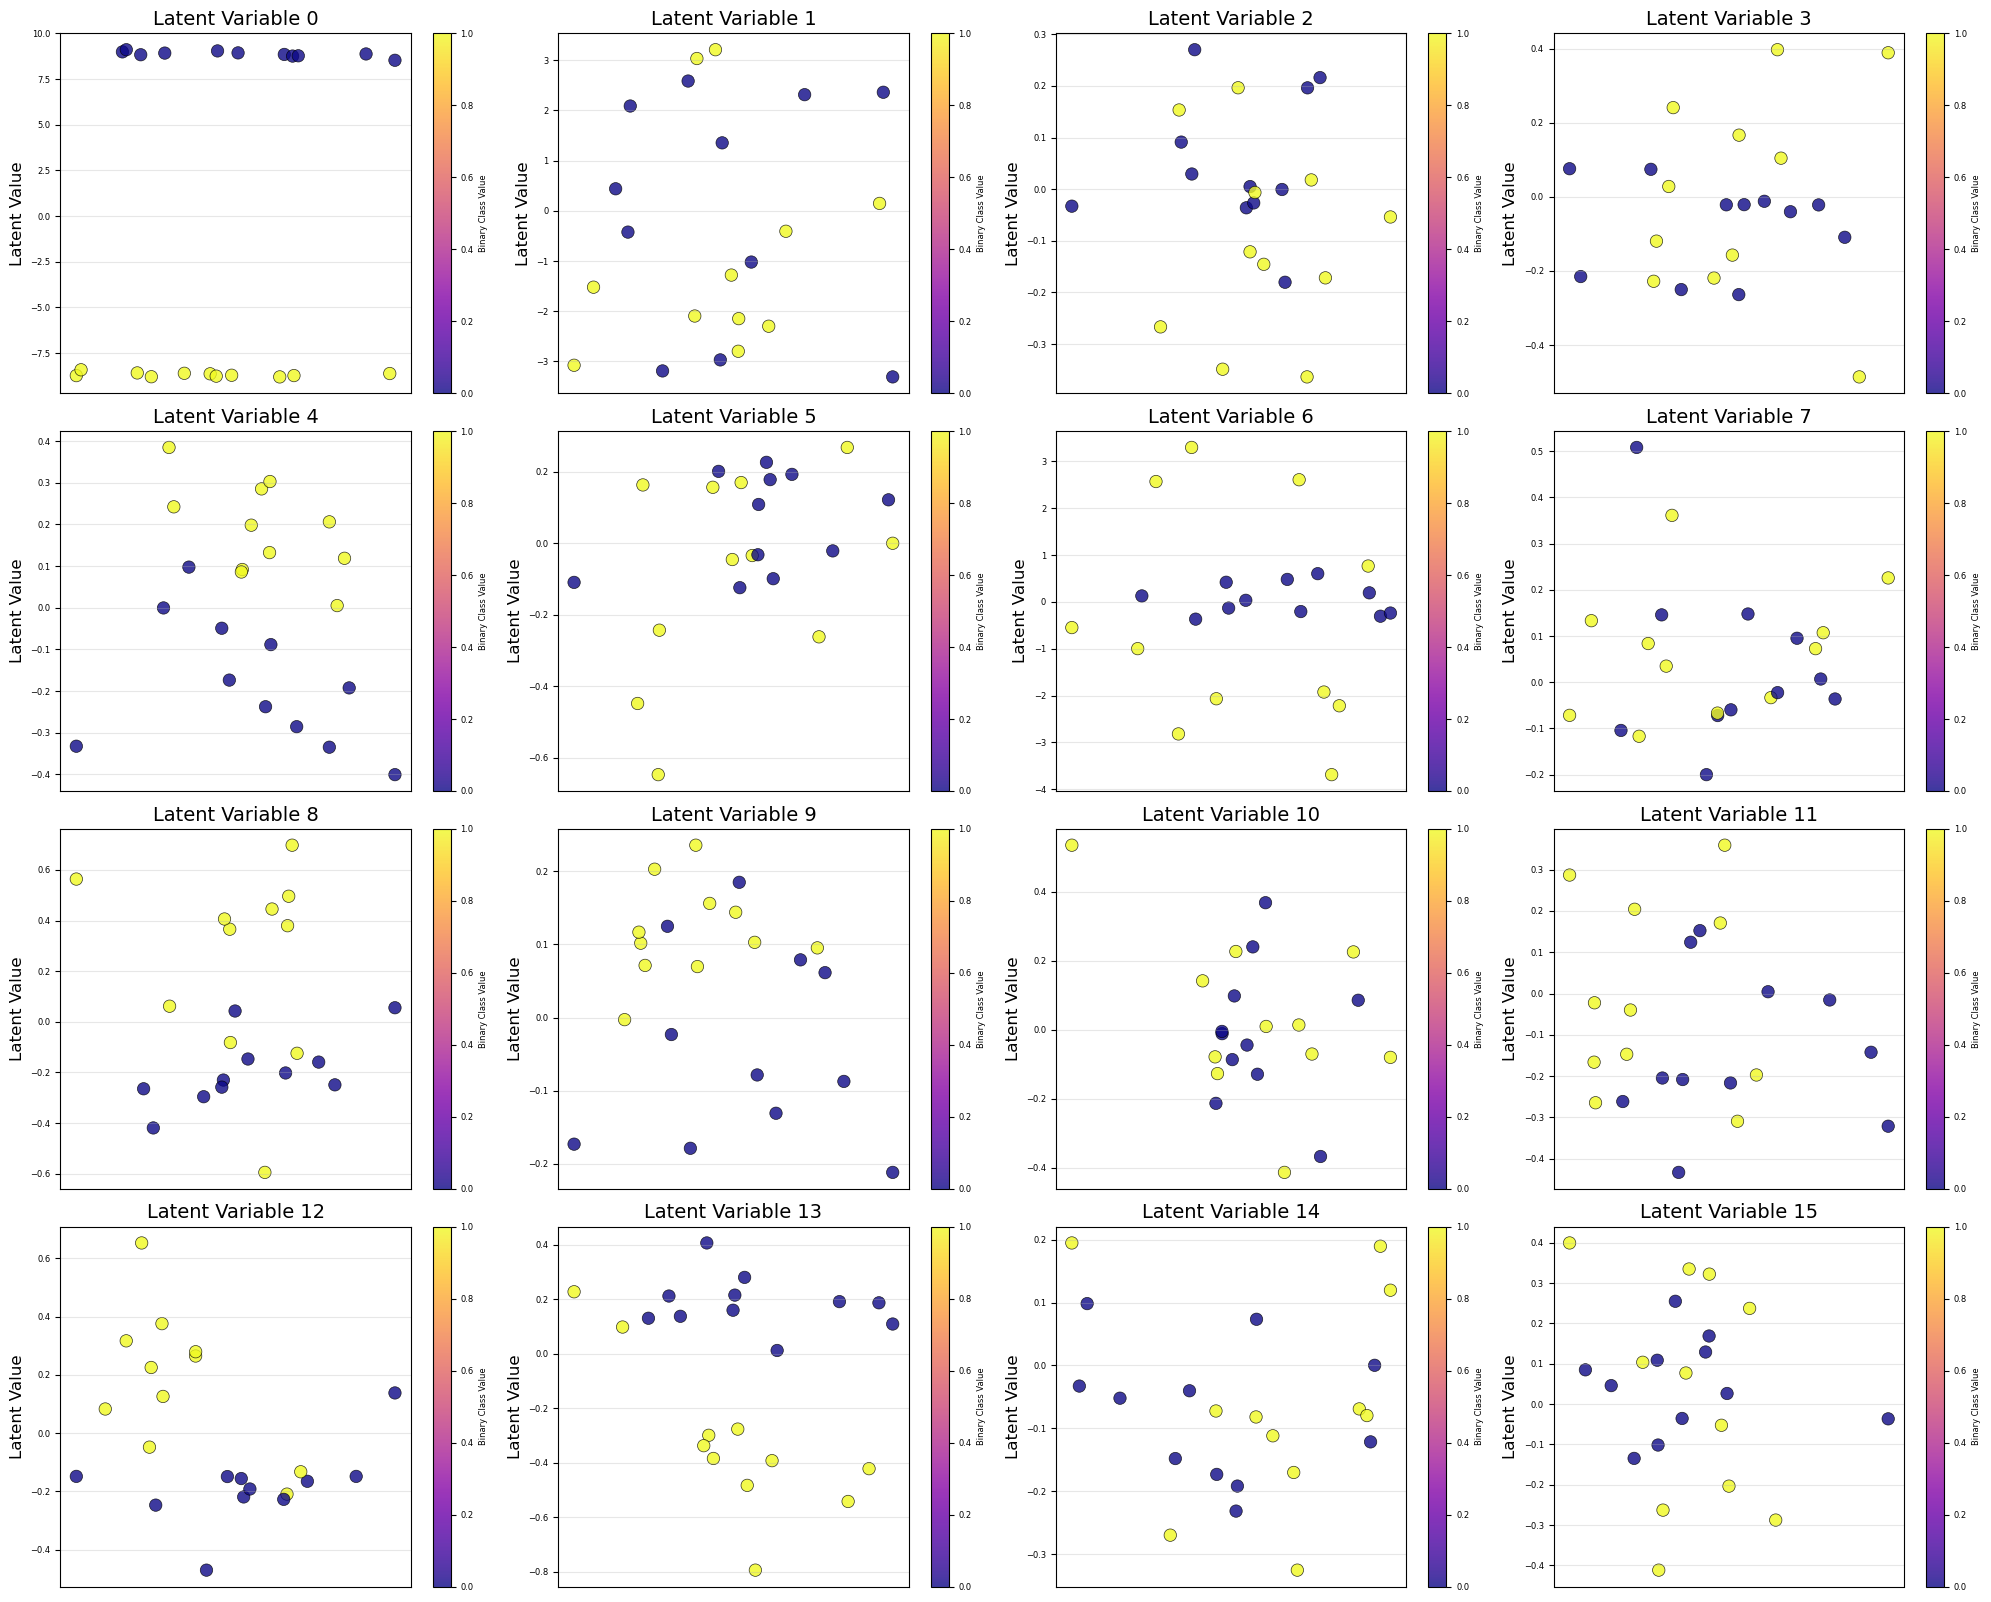

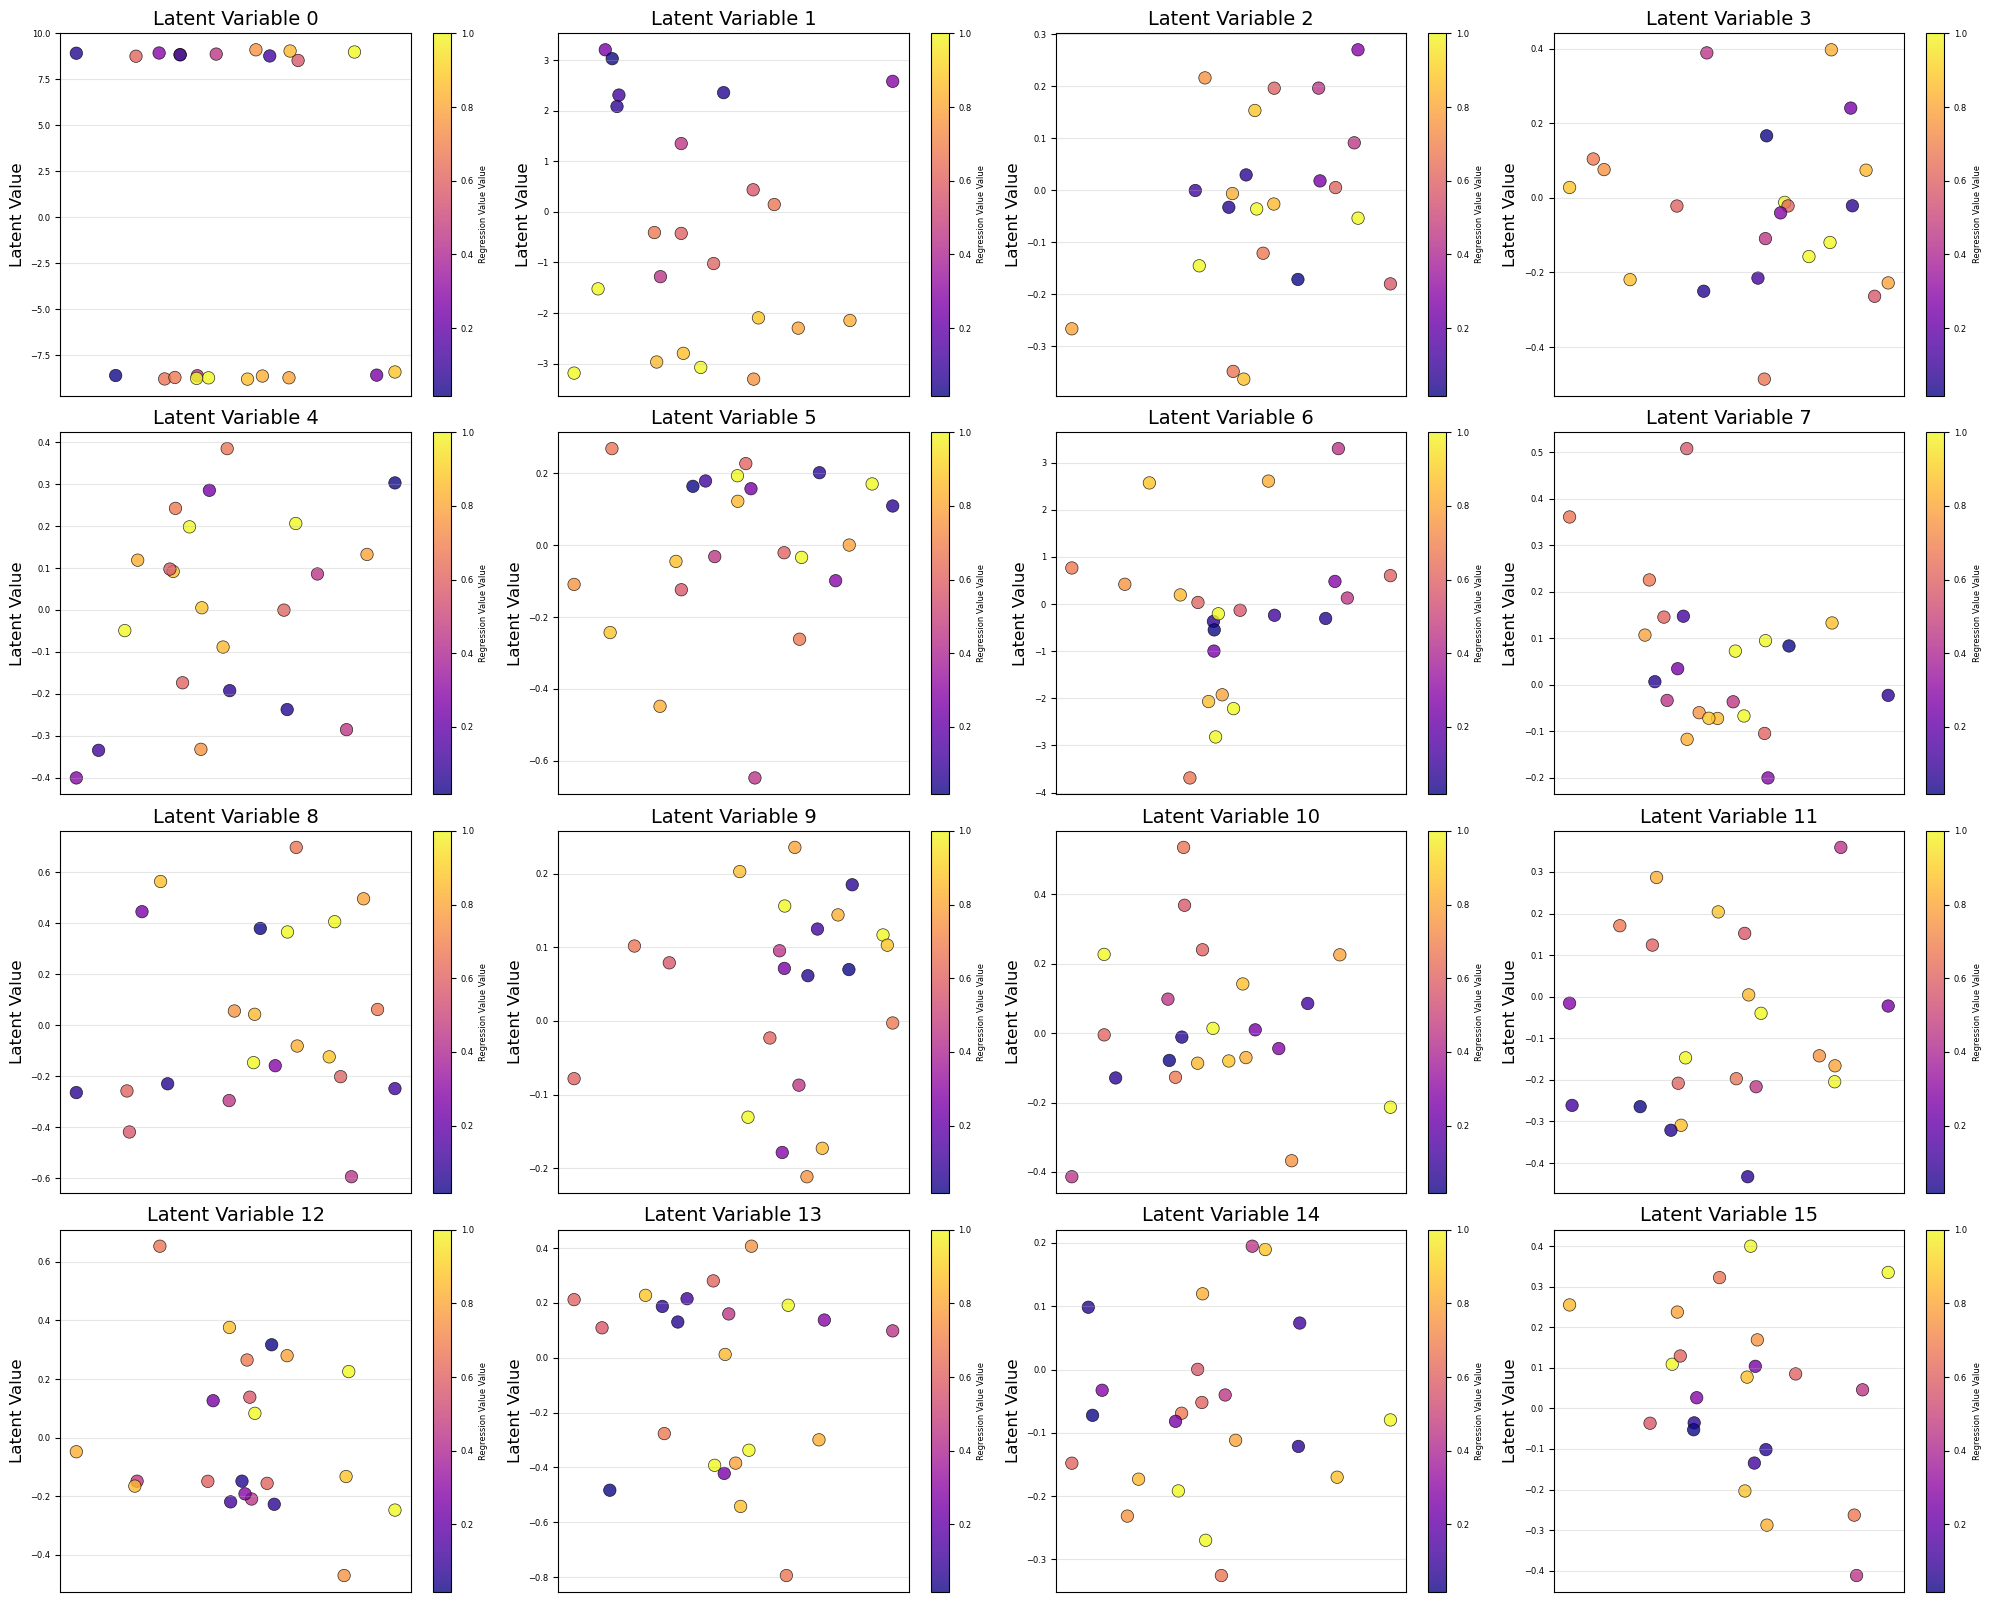

/tmp/ipykernel_1366109/1310241456.py:36: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  scatter = plt.scatter(x_jitter, latent_values,


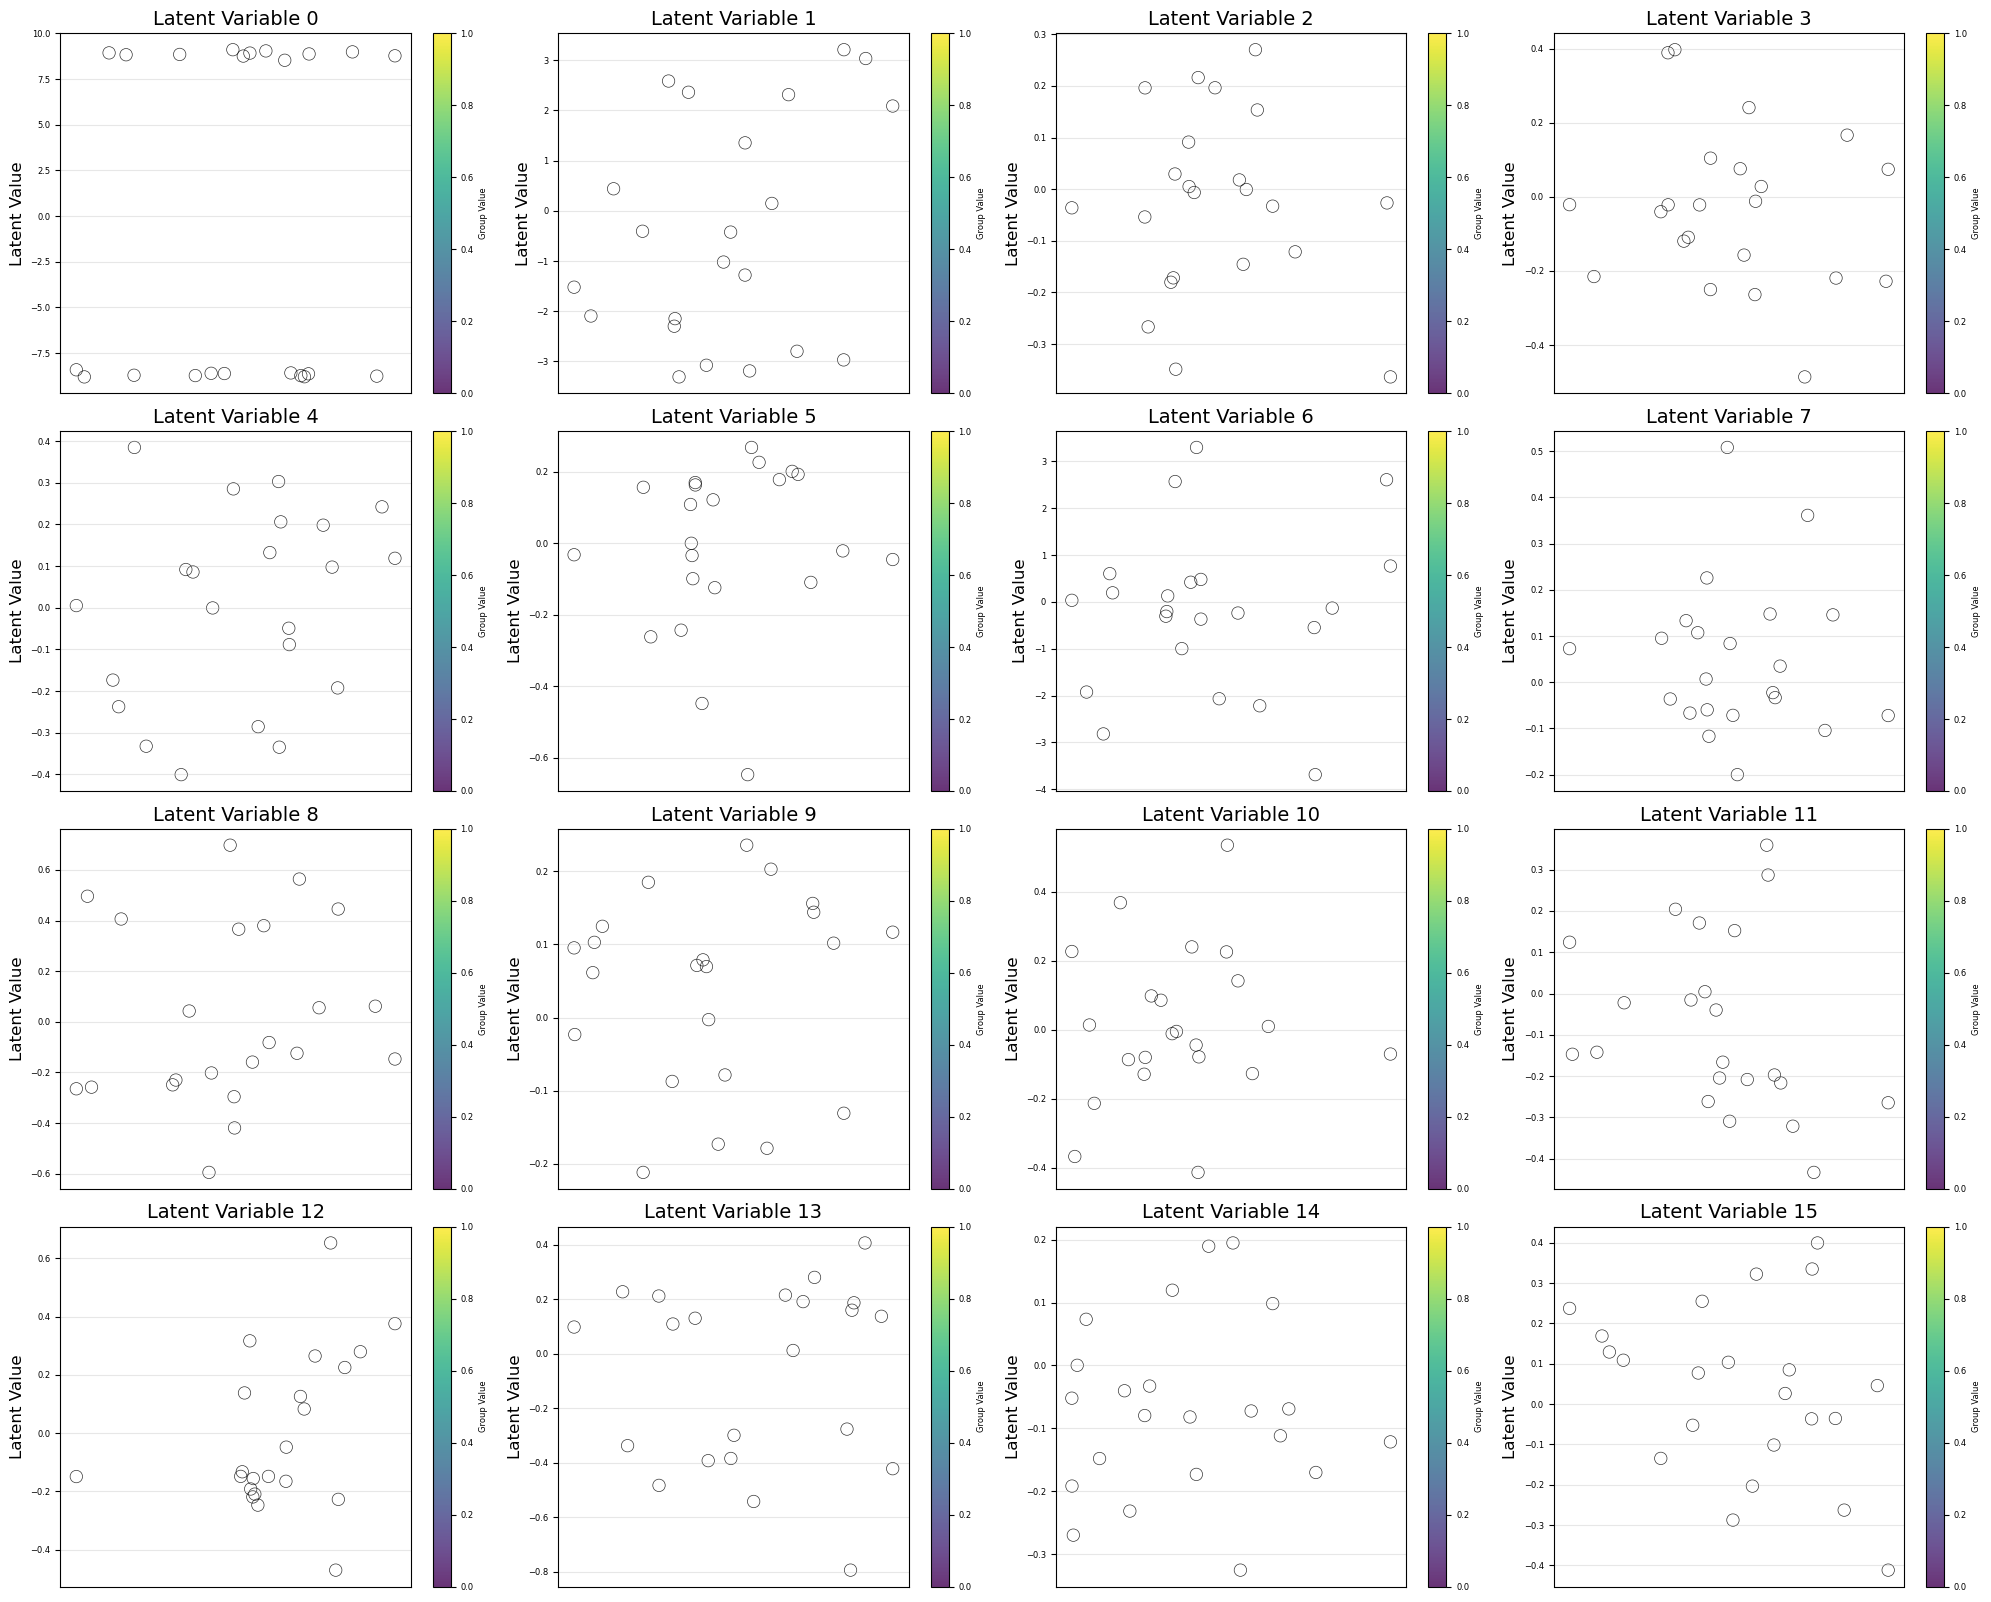

In [19]:
def plot_latent_scatter_by_label(all_latents_array, label_data, label_type, cmap=None):
    """
    Plot scatter plots for all latent variables colored by the given label type.
    
    Args:
        all_latents_array: Array of latent vectors (n_samples x n_dimensions)
        label_data: Array of labels to color points by
        label_type: String name of label type (for title and filename)
        cmap: Optional colormap for continuous values
    """
    # Flatten labels for coloring
    labels_flat = label_data.flatten()
    
    # Unique values for categorical coloring
    unique_values = np.unique(labels_flat)
    is_continuous = len(unique_values) > 10 or np.issubdtype(labels_flat.dtype, np.floating)
    
    # Improved color scheme - better visibility than yellow
    categorical_colors = ['blue', 'darkred', 'darkgreen', 'purple', 'darkorange', 'magenta', 'brown']
    
    plt.figure(figsize=(20, 16))
    
    for i in range(all_latents_array.shape[1]):
        plt.subplot(4, 4, i+1)
        
        # Get values for this latent dimension
        latent_values = all_latents_array[:, i]
        
        # Add jitter to x-axis for better visualization
        x_jitter = np.random.normal(0, 0.1, size=len(latent_values))
        
        # Create scatter plot based on label type
        if is_continuous:
            # Continuous coloring (regression values)
            # Use a better colormap with higher contrast - plasma instead of viridis
            scatter = plt.scatter(x_jitter, latent_values, 
                                 c=labels_flat, cmap=cmap or 'plasma',
                                 alpha=0.8,      # Increased opacity 
                                 s=80,           # Larger point size
                                 edgecolors='black',  # Add black edge for better visibility
                                 linewidth=0.5)
            cbar = plt.colorbar(scatter)
            cbar.set_label(f'{label_type} Value')
        else:
            # Categorical coloring (binary or group)
            for idx, val in enumerate(unique_values):
                mask = labels_flat == val
                # Use color from the improved color scheme
                color = categorical_colors[idx % len(categorical_colors)]
                plt.scatter(x_jitter[mask], latent_values[mask], 
                           c=color, 
                           s=80,           # Larger point size
                           alpha=0.8,      # Increased opacity
                           edgecolors='black',  # Add black edge
                           linewidth=0.5,
                           label=f'{label_type} {int(val)}')
            
            # Only add legend to first plot
            if i == 0:
                plt.legend(fontsize=10, markerscale=1.5)
        
        plt.title(f'Latent Variable {i}', fontsize=14)
        plt.ylabel('Latent Value', fontsize=12)
        plt.xticks([])  # Hide x-ticks
        plt.grid(alpha=0.3)  # Add light grid for better readability
    
    plt.tight_layout()
    plt.savefig(f'latent_variables_by_{label_type.lower().replace(" ", "_")}.png', dpi=300, bbox_inches='tight')
    plt.show()

# Plot all three types of visualizations
label_configs = [
    (all_labels, "Binary Class", None),
    (all_labels_reg, "Regression Value", "plasma"),  # Changed from viridis to plasma
    (all_labels_group, "Group", None)
]

for label_data, label_type, cmap in label_configs:
    plot_latent_scatter_by_label(all_latents_array, label_data, label_type, cmap)

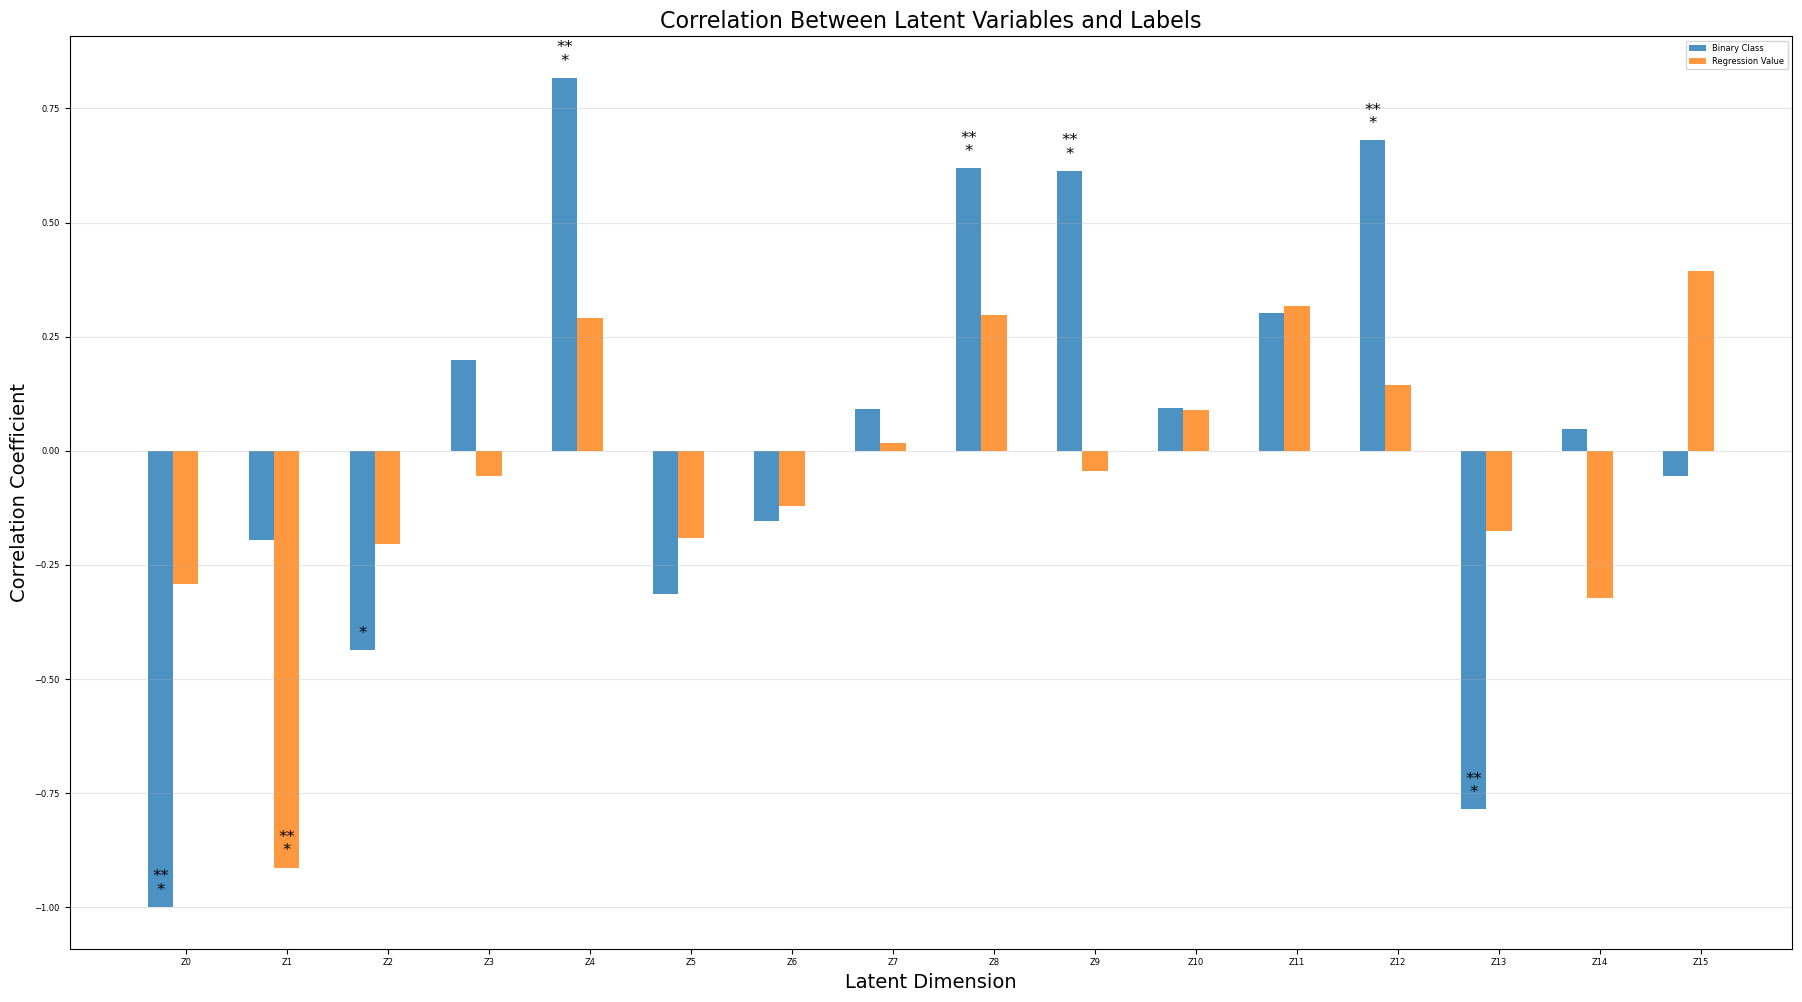


Binary Class correlations with latent variables:
  Z0: -0.9999 (significant) (p=0.0000)
  Z1: -0.1953 (p=0.3837)
  Z2: -0.4364 (significant) (p=0.0423)
  Z3: 0.1998 (p=0.3726)
  Z4: 0.8172 (significant) (p=0.0000)
  Z5: -0.3145 (p=0.1540)
  Z6: -0.1538 (p=0.4944)
  Z7: 0.0913 (p=0.6861)
  Z8: 0.6189 (significant) (p=0.0021)
  Z9: 0.6138 (significant) (p=0.0024)
  Z10: 0.0942 (p=0.6766)
  Z11: 0.3030 (p=0.1704)
  Z12: 0.6801 (significant) (p=0.0005)
  Z13: -0.7857 (significant) (p=0.0000)
  Z14: 0.0477 (p=0.8330)
  Z15: -0.0555 (p=0.8063)
  Top correlated dimensions: Z0 (0.9999), Z4 (0.8172), Z13 (0.7857)

Regression Value correlations with latent variables:
  Z0: -0.2922 (p=0.1870)
  Z1: -0.9130 (significant) (p=0.0000)
  Z2: -0.2037 (p=0.3631)
  Z3: -0.0558 (p=0.8051)
  Z4: 0.2911 (p=0.1887)
  Z5: -0.1912 (p=0.3940)
  Z6: -0.1207 (p=0.5925)
  Z7: 0.0180 (p=0.9365)
  Z8: 0.2978 (p=0.1783)
  Z9: -0.0446 (p=0.8438)
  Z10: 0.0905 (p=0.6888)
  Z11: 0.3170 (p=0.1506)
  Z12: 0.1443 (p=0.521

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import seaborn as sns

def calculate_correlations(latent_array, label_types):
    """
    Calculate correlations between latent variables and different types of labels
    
    Args:
        latent_array: Array of latent vectors (n_samples x n_dimensions)
        label_types: Dict of {label_name: label_array}
    
    Returns:
        Dictionary of correlation matrices for each label type
    """
    results = {}
    
    # Get number of latent dimensions
    n_dims = latent_array.shape[1]
    
    # Process each label type
    for label_name, labels in label_types.items():
        # Flatten labels
        flat_labels = labels.flatten()
        
        # Create correlation matrix
        corr_matrix = np.zeros(n_dims)
        p_values = np.zeros(n_dims)
        
        # Calculate correlation for each latent dimension
        for i in range(n_dims):
            latent_dim = latent_array[:, i]
            
            # For categorical labels with more than 2 categories, use point-biserial or eta correlation
            if label_name == "Group" and len(np.unique(flat_labels)) > 2:
                # Remap values to 0-based for easier processing (1,2 → 0,1)
                remapped_labels = flat_labels - np.min(flat_labels)
                
                # Method 1: For binary categorical, convert to dummy variables and use regular correlation
                # Calculate correlation for each category
                correlations = []
                for val in np.unique(remapped_labels):
                    binary = (remapped_labels == val).astype(float)
                    corr, p = stats.pearsonr(latent_dim, binary)
                    correlations.append(abs(corr))  # Take absolute value
                
                # Use the maximum correlation as the strength indicator
                corr_matrix[i] = max(correlations)
                
                # Alternative: Calculate eta correlation coefficient (correlation ratio)
                # This measures how well a categorical variable predicts a continuous one
                groups = [latent_dim[flat_labels == val] for val in np.unique(flat_labels)]
                ss_total = np.sum((latent_dim - np.mean(latent_dim))**2)
                ss_between = np.sum([len(g) * (np.mean(g) - np.mean(latent_dim))**2 for g in groups])
                eta_squared = ss_between / ss_total if ss_total > 0 else 0
                p_values[i] = 0.05  # Placeholder, eta doesn't have a direct p-value
                
                # Use eta as an alternative measure
                # corr_matrix[i] = np.sqrt(eta_squared)
                
            # For binary or continuous labels, use regular correlation
            else:
                # Check if the label is binary (0/1) or continuous
                if len(np.unique(flat_labels)) <= 2:
                    # Use point-biserial correlation (equivalent to Pearson for binary)
                    corr, p = stats.pointbiserialr(flat_labels, latent_dim)
                else:
                    # Use Pearson correlation for continuous values
                    corr, p = stats.pearsonr(flat_labels, latent_dim)
                
                corr_matrix[i] = corr
                p_values[i] = p
        
        results[label_name] = {
            'correlation': corr_matrix,
            'p_values': p_values
        }
    
    return results

# Prepare your labels
label_types = {
    'Binary Class': all_labels,
    'Regression Value': all_labels_reg,
    #'Group': all_labels_group
}

# Calculate correlations
correlations = calculate_correlations(all_latents_array, label_types)

# Create a nice visualization of the correlations
plt.figure(figsize=(18, 10))

# Set up the plot
bar_width = 0.25
index = np.arange(all_latents_array.shape[1])
opacity = 0.8

# Plot each correlation type
for i, (label_name, corr_data) in enumerate(correlations.items()):
    # Get absolute correlation values for better comparison
    corr_values = corr_data['correlation']
    
    # Plot bars with different colors
    plt.bar(index + i*bar_width, corr_values, bar_width,
            alpha=opacity, color=f'C{i}', label=label_name)
    
    # Mark significant correlations with stars
    for j, p in enumerate(corr_data['p_values']):
        if p < 0.05:
            plt.text(j + i*bar_width, corr_values[j] + 0.02, '*', 
                     ha='center', va='bottom', fontsize=12)
        if p < 0.01:
            plt.text(j + i*bar_width, corr_values[j] + 0.05, '**', 
                     ha='center', va='bottom', fontsize=12)

# Add labels and legend
plt.xlabel('Latent Dimension', fontsize=14)
plt.ylabel('Correlation Coefficient', fontsize=14)
plt.title('Correlation Between Latent Variables and Labels', fontsize=16)
plt.xticks(index + bar_width, [f'Z{i}' for i in range(all_latents_array.shape[1])])
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('latent_correlations.png', dpi=300, bbox_inches='tight')
plt.show()

# Create a more detailed heatmap for each label type
for label_name, corr_data in correlations.items():
    # Print the correlation values
    print(f"\n{label_name} correlations with latent variables:")
    for i, corr in enumerate(corr_data['correlation']):
        p = corr_data['p_values'][i]
        sig = ' (significant)' if p < 0.05 else ''
        print(f"  Z{i}: {corr:.4f}{sig} (p={p:.4f})")
    
    # Identify most correlated dimensions
    abs_corrs = np.abs(corr_data['correlation'])
    top_dims = np.argsort(abs_corrs)[::-1][:3]  # Top 3 dimensions
    print(f"  Top correlated dimensions: {', '.join([f'Z{i} ({abs_corrs[i]:.4f})' for i in top_dims])}")

In [23]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import tree
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import accuracy_score, r2_score, mean_squared_error
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.preprocessing import minmax_scale

def calculate_sap_scores(latent_array, label_types, visualization=True):
    """
    Calculate SAP scores for each label type using the Ubisoft implementation
    
    Args:
        latent_array: Array of latent vectors (n_samples x n_dimensions)
        label_types: Dict of {label_name: label_array}
        visualization: Whether to generate visualizations
        
    Returns:
        Dictionary of SAP scores and detailed score matrices
    """
    results = {}
    s_matrices = {}
    
    # Process each label type
    for label_name, label_array in label_types.items():
        # Determine factor type
        is_continuous = (len(np.unique(label_array)) > 10) or np.issubdtype(label_array.dtype, np.floating)
        is_binary = len(np.unique(label_array)) <= 2

        # Use appropriate SAP calculation
        if is_continuous:
            # Regression for continuous values
            score, s_matrix = calculate_sap_for_factor(
                label_array, latent_array, 
                continuous_factors=True, 
                regression=True
            )
        else:
            # Classification for binary/categorical
            score, s_matrix = calculate_sap_for_factor(
                label_array, latent_array, 
                continuous_factors=False, 
                regression=False
            )
        
        # Save results
        results[label_name] = score
        s_matrices[label_name] = s_matrix
    
    # Calculate normalized scores (0-1 range)
    normalized_results = {}
    for label_name, score in results.items():
        normalized_results[label_name] = min(max(score, 0.0), 1.0)
    
    # Generate visualizations
    if visualization:
        # Plot score matrices
        for label_name, s_matrix in s_matrices.items():
            plt.figure(figsize=(10, 4))
            plt.imshow(s_matrix, cmap='viridis', aspect='auto')
            plt.colorbar(label='Score')
            plt.xlabel('Latent Dimension')
            plt.ylabel('Factor')
            plt.title(f'SAP Score Matrix for {label_name}')
            plt.tight_layout()
            plt.savefig(f'sap_matrix_{label_name.lower().replace(" ", "_")}.png', dpi=300)
            plt.close()
        
        # Plot original and normalized SAP scores
        plt.figure(figsize=(12, 6))
        
        # Set up bar plot
        labels = list(results.keys())
        x = np.arange(len(labels))
        width = 0.35
        
        # Original scores
        plt.bar(x - width/2, list(results.values()), width, label='Original SAP')
        
        # Normalized scores
        plt.bar(x + width/2, list(normalized_results.values()), width, label='Normalized SAP (0-1)')
        
        # Add labels
        plt.xlabel('Attribute Type', fontsize=14)
        plt.ylabel('SAP Score', fontsize=14)
        plt.title('SAP Scores by Attribute Type', fontsize=16)
        plt.xticks(x, labels)
        plt.legend()
        plt.grid(axis='y', alpha=0.3)
        plt.tight_layout()
        plt.savefig('sap_scores_comparison.png', dpi=300)
        plt.close()
    
    return {
        'original': results,
        'normalized': normalized_results,
        'matrices': s_matrices
    }

def calculate_sap_for_factor(factors, codes, continuous_factors=True, regression=True, nb_bins=10):
    """
    Calculate SAP for a single factor using the Ubisoft implementation
    
    Args:
        factors: Array of factor values
        codes: Array of latent codes
        continuous_factors: Whether the factor is continuous
        regression: Whether to use regression or classification
        nb_bins: Number of bins for discretization
        
    Returns:
        SAP score and score matrix
    """
    # Reshape inputs if needed
    if len(factors.shape) == 1:
        factors = factors.reshape(-1, 1)
    
    # Count dimensions
    nb_factors = factors.shape[1]
    nb_codes = codes.shape[1]
    
    # Calculate SAP matrices and scores
    if regression:
        assert continuous_factors, "Cannot perform SAP regression with discrete factors."
        s_matrix = np.zeros((nb_factors, nb_codes))
        
        # Calculate R2 score matrix
        for f in range(nb_factors):
            for c in range(nb_codes):
                # Train a linear regressor
                regr = LinearRegression()
                regr.fit(codes[:, c].reshape(-1, 1), factors[:, f].reshape(-1, 1))
                
                # Make predictions
                y_pred = regr.predict(codes[:, c].reshape(-1, 1))
                
                # Compute R2 score
                r2 = r2_score(factors[:, f], y_pred)
                s_matrix[f, c] = max(0, r2)
        
    else:
        # For classification
        # Quantize factors if continuous
        if continuous_factors:
            factors_norm = minmax_scale(factors.copy())  # normalize to [0,1]
            factors_quantized = np.zeros_like(factors_norm, dtype=int)
            for f in range(factors_norm.shape[1]):
                factors_quantized[:, f] = get_bin_index(factors_norm[:, f], nb_bins)
            factors = factors_quantized
        
        # Normalize codes to [0,1]
        codes_norm = minmax_scale(codes.copy())
        
        # Calculate accuracy matrix
        s_matrix = np.zeros((nb_factors, nb_codes))
        for f in range(nb_factors):
            for c in range(nb_codes):
                # Find optimal tree depth
                best_score, best_sp = 0, 0
                for sp in range(1, 10):
                    # Cross-validation
                    clf = tree.DecisionTreeClassifier(max_depth=sp)
                    scores = cross_val_score(
                        clf, 
                        codes_norm[:, c].reshape(-1, 1), 
                        factors[:, f].reshape(-1, 1), 
                        cv=5
                    )
                    score = scores.mean()
                    
                    if score > best_score:
                        best_score = score
                        best_sp = sp
                
                # Train final model with best depth
                clf = tree.DecisionTreeClassifier(max_depth=best_sp)
                clf.fit(codes_norm[:, c].reshape(-1, 1), factors[:, f].reshape(-1, 1))
                
                # Make predictions
                y_pred = clf.predict(codes_norm[:, c].reshape(-1, 1))
                
                # Compute accuracy
                s_matrix[f, c] = accuracy_score(factors[:, f], y_pred)
    
    # Compute the gap for all factors
    sum_gap = 0
    for f in range(nb_factors):
        # Get difference between highest and second highest
        s_f = np.sort(s_matrix[f, :])
        if len(s_f) >= 2:
            sum_gap += s_f[-1] - s_f[-2]
        else:
            sum_gap += s_f[-1]
    
    # Compute mean gap
    sap_score = sum_gap / nb_factors
    
    return sap_score, s_matrix

def get_bin_index(x, nb_bins):
    """
    Discretize input variable
    
    Args:
        x: Input variable
        nb_bins: Number of bins for discretization
    
    Returns:
        Discretized variable
    """
    # Get bin limits
    bins = np.linspace(0, 1, nb_bins + 1)
    
    # Discretize input variable
    return np.digitize(x, bins[:-1], right=False).astype(int)

# Example usage with your data
label_types = {
    'Binary Class': all_labels,
    'Regression Value': all_labels_reg,
    #'Group': all_labels_group
}

# Calculate SAP scores and generate visualizations
sap_results = calculate_sap_scores(all_latents_array, label_types)

# Print results
print("\nSAP Scores (Original Implementation):")
for label_name, score in sap_results['original'].items():
    print(f"{label_name}: {score:.4f}")


# Calculate per-dimension importance for each factor
print("\nMost important latent dimensions for each factor:")
for label_name, s_matrix in sap_results['matrices'].items():
    # Get the most important dimension for each factor
    for f in range(s_matrix.shape[0]):
        best_dim = np.argmax(s_matrix[f, :])
        score = s_matrix[f, best_dim]
        print(f"{label_name} - Factor {f}: Z{best_dim} (Score: {score:.4f})")


SAP Scores (Original Implementation):
Binary Class: 0.3319
Regression Value: 0.6775

Most important latent dimensions for each factor:
Binary Class - Factor 0: Z0 (Score: 0.9998)
Regression Value - Factor 0: Z1 (Score: 0.8335)


In [13]:
print(f"SAP scores (attribute vae): {sap_score}")

SAP scores: 0.045454545454545414


In [11]:
print(f"SAP scores (contrastive one variable): {sap_score}")

SAP scores (contrastive one variable): 0.09090909090909094


In [ ]:
print(all_labels)

In [10]:
test_latents = np.load(path)

In [12]:
latent_min = np.min(test_latents, axis=0)
latent_max = np.max(test_latents, axis=0)

print("Minimum values for each latent variable:", latent_min)
print("Maximum values for each latent variable:", latent_max)

Minimum values for each latent variable: [-0.6954266  -1.1536734  -0.47461104 -0.4344825  -0.57577467 -0.46523276
 -0.24694285 -0.49584898 -0.4581654  -0.44499192 -0.51410025 -0.63719094
 -0.4197298  -0.55275875 -0.5489806  -0.5510489 ]
Maximum values for each latent variable: [0.40666306 0.5711539  0.56581724 0.51912546 0.47664177 0.38276148
 0.33223683 0.73687285 0.6121826  0.45838717 0.6537683  0.43149415
 0.3252261  0.3948623  0.5224641  0.36176726]


In [14]:
latent_mean = np.mean(test_latents, axis=0)
latent_std = np.std(test_latents, axis=0)

print("Mean for each latent variable:", latent_mean)
print("Standard deviation for each latent variable:", latent_std)

Mean for each latent variable: [-0.0676787  -0.35337508 -0.05779378 -0.01753479  0.0125681  -0.02355604
  0.06498463  0.08168843 -0.07228059  0.04351648 -0.02543143  0.05087868
 -0.04577363 -0.04326111  0.05849929  0.00062894]
Standard deviation for each latent variable: [0.34588236 0.472742   0.28920478 0.24459042 0.2886332  0.21806082
 0.1952848  0.3078662  0.29442194 0.2431323  0.27060866 0.26424357
 0.21766897 0.2828115  0.2795713  0.23889777]


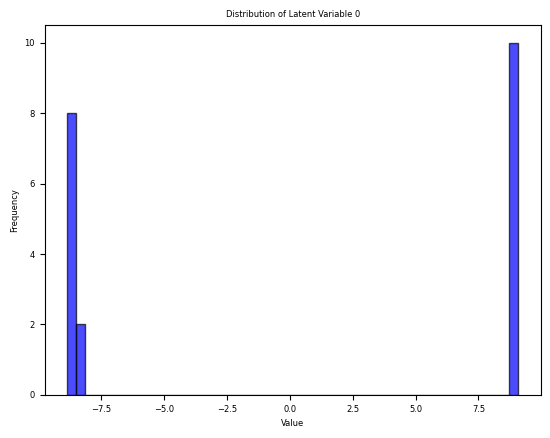

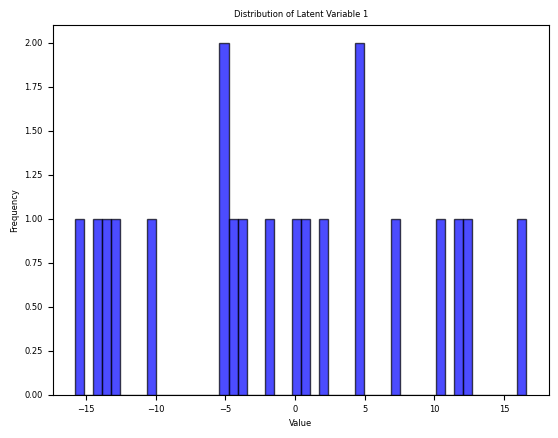

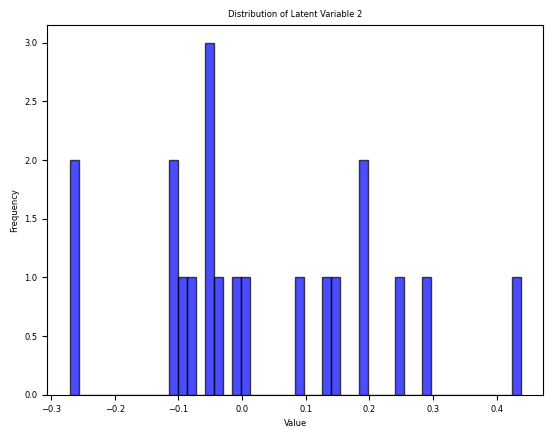

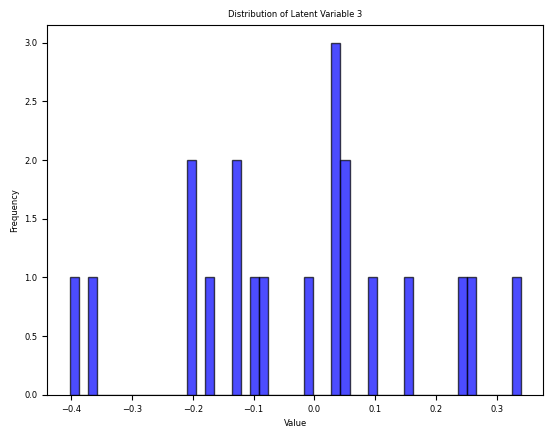

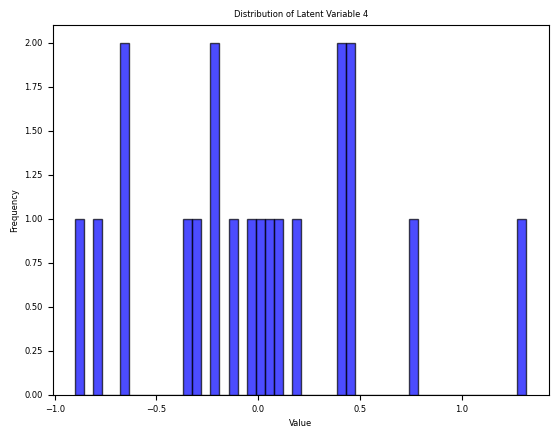

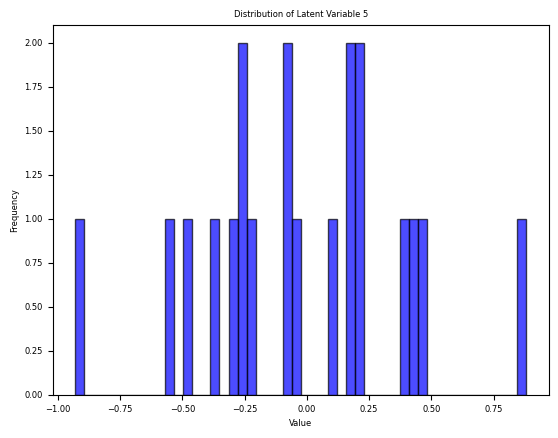

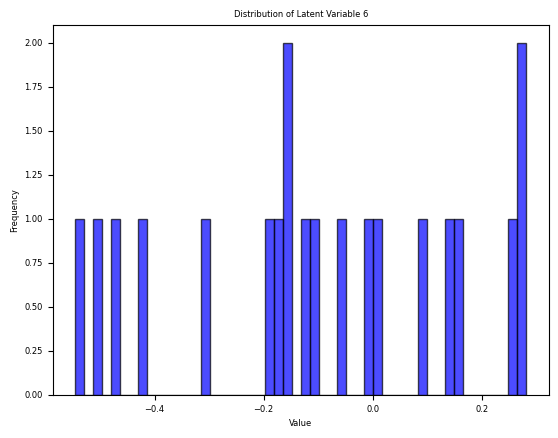

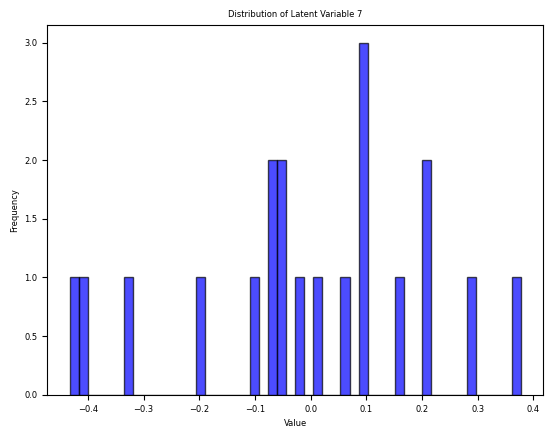

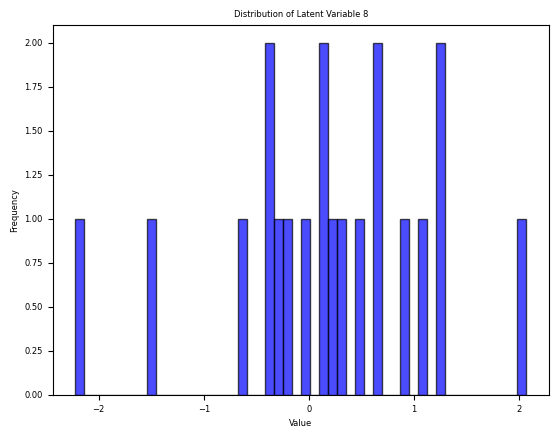

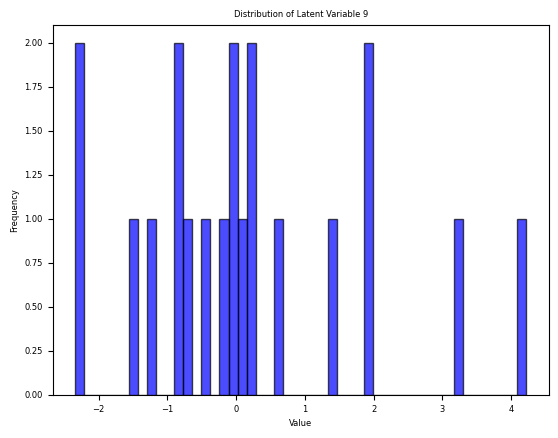

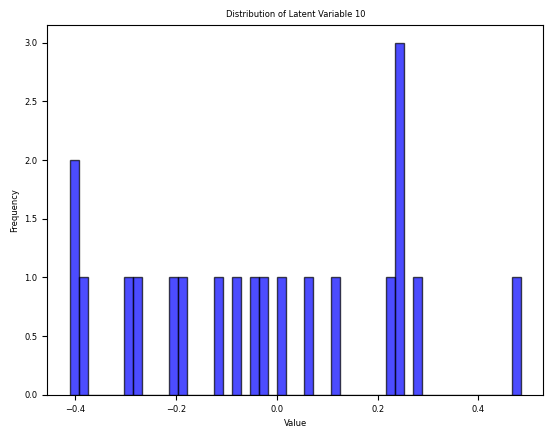

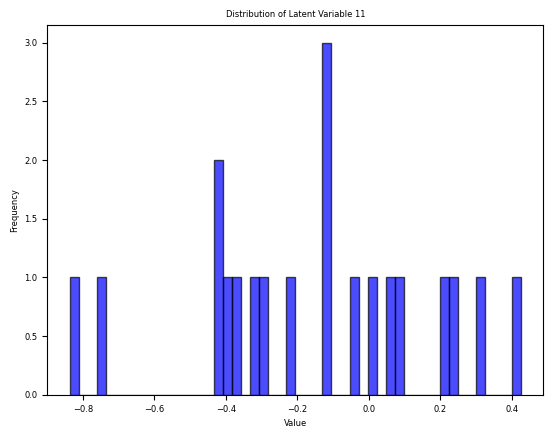

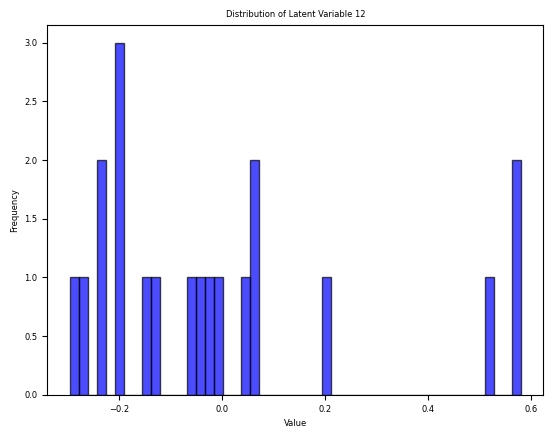

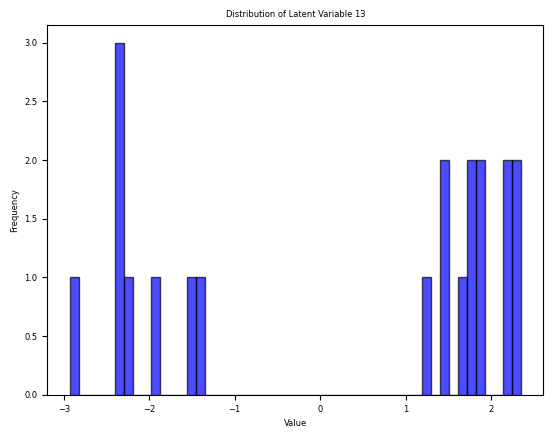

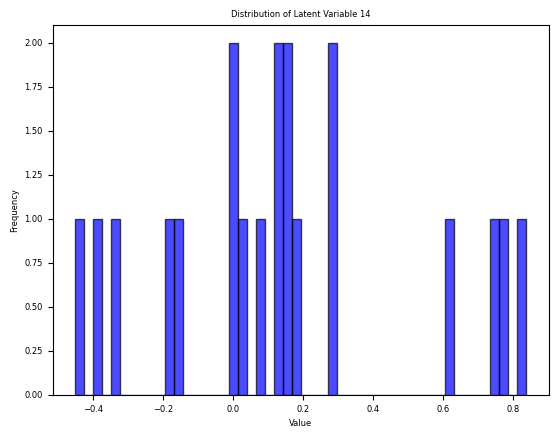

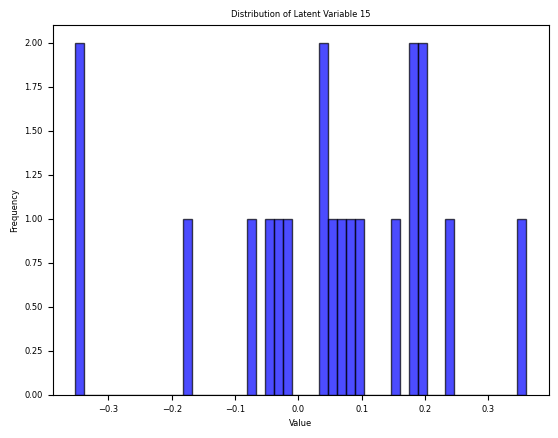

In [26]:
# Loop over each latent variable and display the plot
for i in range(all_latents_array.shape[1]):
    plt.figure()
    plt.hist(all_latents_array[:, i], bins=50, alpha=0.7, color='blue', edgecolor='black')
    plt.title(f"Distribution of Latent Variable {i}")
    plt.xlabel("Value")
    plt.ylabel("Frequency")
    
    # Show the plot inline in the notebook
    plt.show()